# 06 — What rain does each circulation type actually produce?

Notebook 04 classified 137 heavy El Niño days into nine 850 hPa wind patterns, and notebook 05
asked whether the nodes differ in moisture *transport*. Both described each node with a single
number for rainfall: the Guayas-province mean. That is enough to rank nodes, and not nearly
enough to see what distinguishes them.

A province mean cannot tell you whether a wet node is wet because rain fell everywhere at a
moderate rate, or because a narrow band sat over the coastal plain, or because the Andean
slope did what it always does while the lowlands stayed dry. Those are different weather
situations with different consequences, and they can share a mean.

This notebook composites the **gridded** daily fields within each node, from two independent
precipitation products:

1. **Mean daily rainfall** per node — where the rain fell, not just how much.
2. **Exceedance frequency** at 25 and 50 mm/day — how often each cell got a genuinely heavy
   day, which is not the same map as the mean.
3. **CHIRPS against IMERG**, node by node — because notebook 01 showed their disagreement is
   intensity-dependent, and these are the highest-intensity days in the record.

## The pattern this notebook is really about: reduce where the data lives

The CHIRPS store is 4.1 GB and IMERG 1.6 GB. Producing the CHIRPS composites below meant
reading **1.23 GB** — the 137 days are scattered across 21 of the store's 46 annual time-chunks,
and Zarr reads whole chunks, so a sparse day list still touches nearly half the archive (the
chunk-geometry point from notebook 03, met again from the other direction). The answer that
comes out the far end is **2.0 MB**: a 613× reduction.

Doing that reduction on a laptop means pulling 1.23 GB across the network. Doing it next to the
store means moving 2.0 MB.

So the reduction lives in `src/composites.py`, importable and with no plotting dependency, and
`scripts/compute_node_composites.py` runs it next to the stores. This notebook calls the *same
function*: if the small result is already in `data/` it loads it, and if not — and you can see
the stores — it computes it here. The outputs below were produced by the cluster path, since
the stores in question sit behind a group filesystem that has no plotting stack installed.

That split is not a workaround for this particular cluster. It is the normal shape of analysis
against remote archives, and it is worth building in from the start rather than discovering it
when a notebook tries to stream 30 GB through a laptop.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import xarray as xr

from config import (CHIRPS_ZARR, IMERG_ZARR, DATA_DIR, FIG_DIR, ECUADOR_EXTENT,
                    PRECIP_THRESHOLDS, SOM_GRID, PROVINCES_GPKG, ETOPO_NC,
                    TERRAIN_CONTOUR_M)
from composites import node_precip_composites

N_NODES = SOM_GRID[0] * SOM_GRID[1]
print("extent     :", ECUADOR_EXTENT)
print("thresholds :", PRECIP_THRESHOLDS, "mm/day")
print("nodes      :", N_NODES)

extent     : (-81.4, -74.9, -5.3, 1.8)
thresholds : [25, 50] mm/day
nodes      : 9


## 1. Load the node assignments

Prefer the assignments notebook 04 wrote; fall back to the shipped reference copy so this
notebook stands alone. They are identical when 04 has been run — 04 verifies that explicitly.

In [2]:
assign_path = DATA_DIR / "som_node_assignments.csv"
if not assign_path.exists():
    assign_path = DATA_DIR / "som_node_assignments_reference.csv"
assignments = pd.read_csv(assign_path, parse_dates=["date"])

print(f"source: {assign_path.name}   days: {len(assignments)}")
print("\ndays per node:")
print(assignments["som_node"].value_counts().reindex(range(N_NODES)).to_string())

source: som_node_assignments.csv   days: 137

days per node:
som_node
0     4
1    26
2     9
3    13
4    18
5     8
6    20
7    27
8    12


## 2. Load or compute the composites

`node_precip_composites()` is the same function the cluster driver calls. The cache check is
what makes this notebook runnable without the stores; the `else` branch is what ran to produce
the cached files.

In [3]:
def load_or_compute(store, cache_name):
    path = DATA_DIR / cache_name
    if path.exists():
        ds = xr.open_dataset(path)
        print(f"{cache_name}: loaded from cache "
              f"({ds.attrs.get('n_days_covered')} of "
              f"{ds.attrs.get('n_days_requested')} days covered)")
        return ds
    print(f"{cache_name}: not cached -- computing from {store}")
    ds = node_precip_composites(store, assignments, ECUADOR_EXTENT,
                                thresholds=PRECIP_THRESHOLDS, n_nodes=N_NODES)
    ds.to_netcdf(path)
    return ds

chirps = load_or_compute(CHIRPS_ZARR, "chirps_som_node_composites.nc")
imerg = load_or_compute(IMERG_ZARR, "imerg_som_node_composites.nc")

for name, ds in [("CHIRPS", chirps), ("IMERG", imerg)]:
    print(f"\n{name}: grid {ds.sizes['lat']}x{ds.sizes['lon']}, "
          f"fields {[v for v in ds.data_vars if v != 'n_days']}")
    print("  n_days per node:", ds.n_days.values)

chirps_som_node_composites.nc: loaded from cache (137 of 137 days covered)
imerg_som_node_composites.nc: loaded from cache (84 of 137 days covered)

CHIRPS: grid 142x130, fields ['mean_precip', 'freq_gt25', 'freq_gt50']
  n_days per node: [ 4 26  9 13 18  8 20 27 12]

IMERG: grid 71x65, fields ['mean_precip', 'freq_gt25', 'freq_gt50']
  n_days per node: [ 2 18  7 10 14  2 12 12  7]


**The two `n_days` rows are not the same, and that is not a bug.** CHIRPS begins in 1981 and
covers all 137 days. IMERG begins in June 2000 and covers only the subset that falls after that.
Every IMERG panel below therefore rests on fewer days than its CHIRPS counterpart, and two nodes
fall to a handful. Sample size is annotated on every panel for exactly this reason.

## 3. Mapping helper

One function, reused for every field and both products, so the panels are strictly comparable:
same projection, same extent, same province and terrain reference layers, and — critically — the
**same colour scale across all nine nodes** within a figure. Rescaling per panel would make every
node look equally intense and destroy the comparison the figure exists to make.

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs          # cartopy cache dir is set by config.py
import cartopy.feature as cfeature
import geopandas as gpd

prov = gpd.read_file(PROVINCES_GPKG)
topo = xr.open_dataarray(ETOPO_NC)
proj = ccrs.PlateCarree()


def node_map_grid(ds, field, cmap, vmax, cbar_label, title, fname,
                  vmin=0, extend="max"):
    norm = mpl.colors.Normalize(vmin, vmax)
    fig, axes = plt.subplots(3, 3, figsize=(9.5, 10.4),
                             subplot_kw=dict(projection=proj),
                             gridspec_kw=dict(wspace=0.04, hspace=0.10))
    for k in range(N_NODES):
        ax = axes[k // 3, k % 3]
        ax.set_extent(ECUADOR_EXTENT, crs=proj)
        n = int(ds.n_days.values[k])
        if n > 0:
            ax.pcolormesh(ds.lon, ds.lat, ds[field].isel(node=k).values,
                          cmap=cmap, norm=norm, transform=proj,
                          rasterized=True, shading="auto")
        else:
            ax.text(0.5, 0.5, "no days", ha="center", va="center",
                    transform=ax.transAxes, fontsize=8, color="0.5")
        ax.coastlines(resolution="10m", linewidth=0.5, color="0.15")
        ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.4, color="0.15")
        prov.boundary.plot(ax=ax, linewidth=0.3, edgecolor="0.45", transform=proj)
        ax.contour(topo.lon, topo.lat, topo.values, levels=[TERRAIN_CONTOUR_M],
                   colors="#b2182b", linewidths=0.6, transform=proj)
        # n is part of the reading of every panel, so it goes in the title
        ax.set_title(f"Node {k}  (n={n})", fontsize=9, pad=3,
                     color="0.45" if 0 < n < 5 else "black")
        ax.set_xticks([]); ax.set_yticks([])

    # colourbar sits above the footnote with room for its own label between them;
    # tick labels render below the bar, so the gap has to clear those too
    cax = fig.add_axes([0.28, 0.090, 0.44, 0.014])
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax,
                      orientation="horizontal", extend=extend)
    cb.set_label(cbar_label, fontsize=9, labelpad=5)
    cb.ax.tick_params(labelsize=7.5)
    fig.suptitle(title, fontsize=11.5, y=0.975)
    fig.text(0.5, 0.018,
             "Red: 750 m elevation contour.  Grey: province boundaries.  "
             "Grey node titles (n<5) are too small to interpret.",
             ha="center", fontsize=7.5, color="0.35")
    fig.subplots_adjust(left=0.02, right=0.98, top=0.935, bottom=0.145)
    fig.savefig(FIG_DIR / fname, dpi=150)
    return fig

## 4. CHIRPS composites

Three fields, one figure each. Read them together: the mean map says where rain fell on a
typical day of that type; the exceedance maps say how often it fell *hard*, which is the
quantity that matters for flooding and which the mean can hide.

/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it

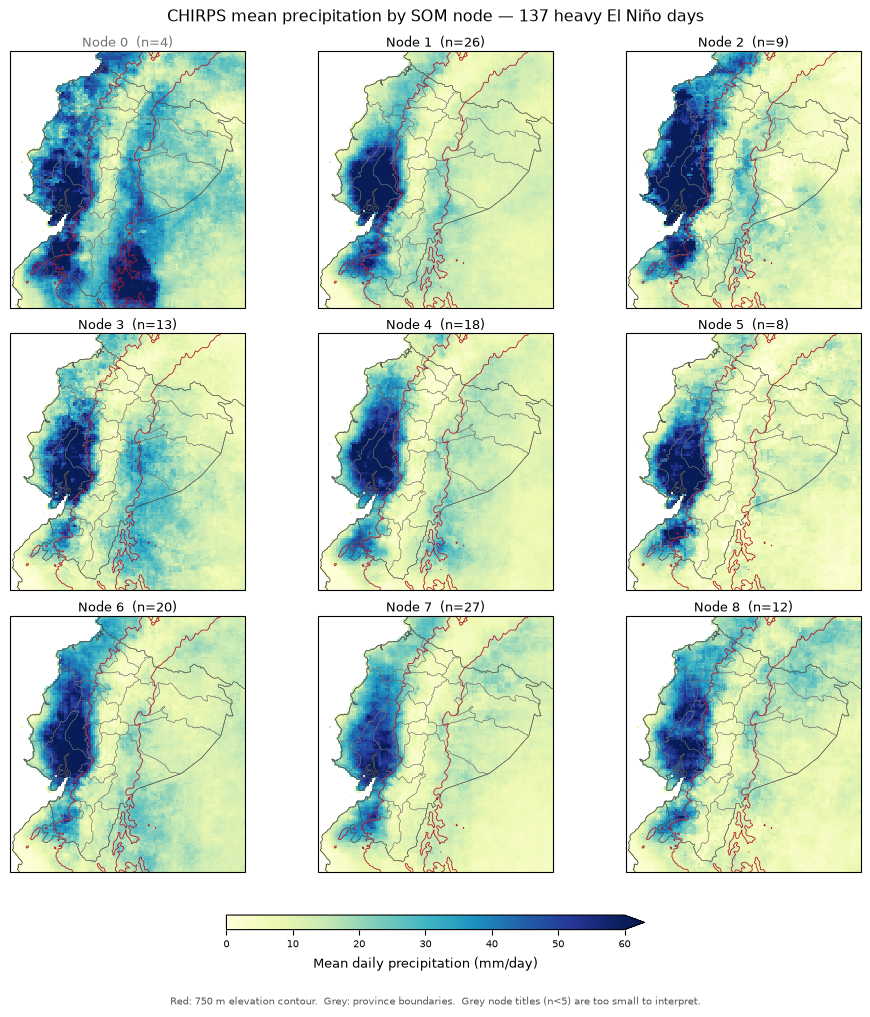

In [5]:
fig_c_mean = node_map_grid(
    chirps, "mean_precip", plt.get_cmap("YlGnBu"), vmax=60,
    cbar_label="Mean daily precipitation (mm/day)",
    title="CHIRPS mean precipitation by SOM node — 137 heavy El Niño days",
    fname="06_chirps_node_mean.png")

/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it

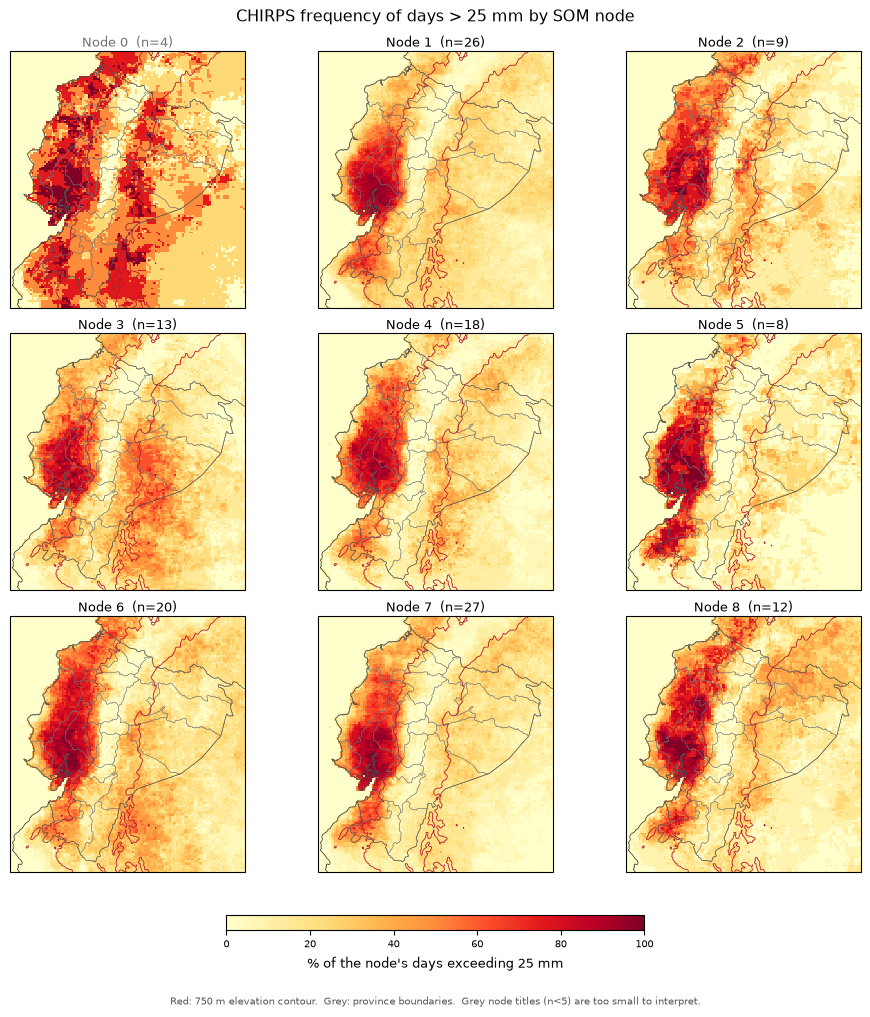

In [6]:
fig_c_25 = node_map_grid(
    chirps, "freq_gt25", plt.get_cmap("YlOrRd"), vmax=100,
    cbar_label="% of the node's days exceeding 25 mm",
    title="CHIRPS frequency of days > 25 mm by SOM node",
    fname="06_chirps_node_freq25.png", extend="neither")

/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it

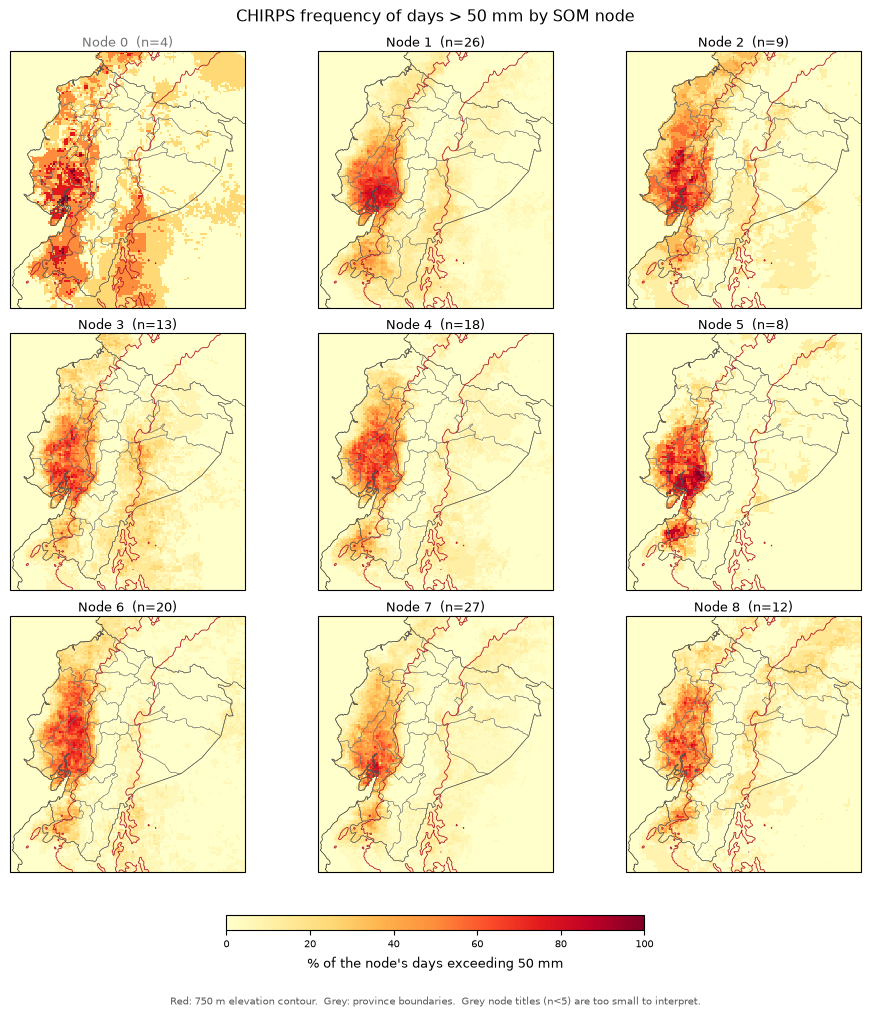

In [7]:
fig_c_50 = node_map_grid(
    chirps, "freq_gt50", plt.get_cmap("YlOrRd"), vmax=100,
    cbar_label="% of the node's days exceeding 50 mm",
    title="CHIRPS frequency of days > 50 mm by SOM node",
    fname="06_chirps_node_freq50.png", extend="neither")

## 5. IMERG composites

The same three fields from an independent product, on the same colour scales so the panels can
be compared directly against the CHIRPS figures above. Note the smaller `n` on every panel.

/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it

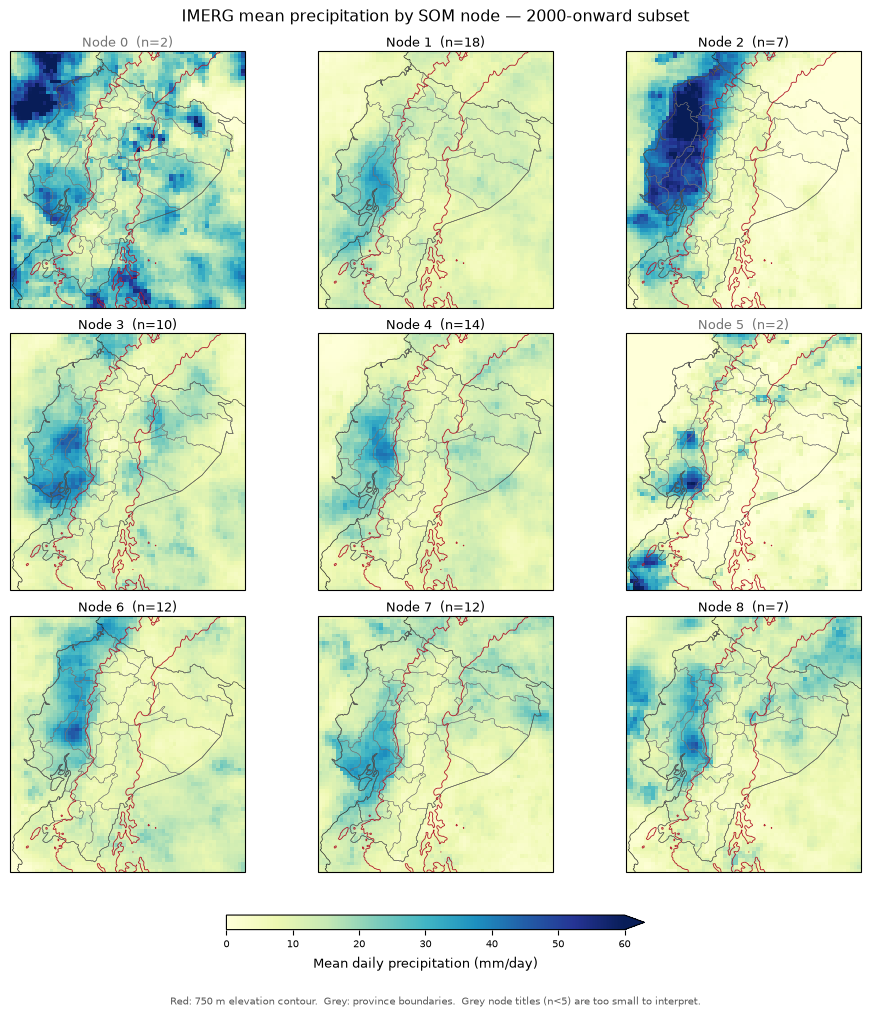

In [8]:
fig_i_mean = node_map_grid(
    imerg, "mean_precip", plt.get_cmap("YlGnBu"), vmax=60,
    cbar_label="Mean daily precipitation (mm/day)",
    title="IMERG mean precipitation by SOM node — 2000-onward subset",
    fname="06_imerg_node_mean.png")

/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it

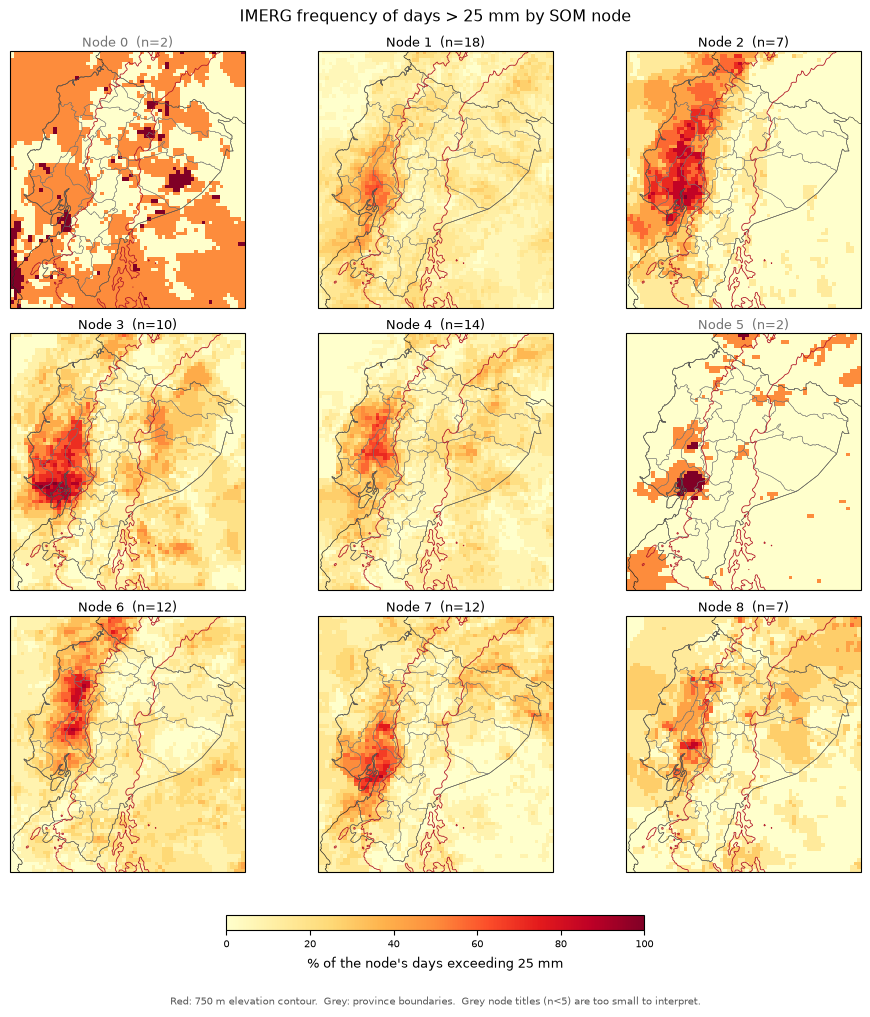

In [9]:
fig_i_25 = node_map_grid(
    imerg, "freq_gt25", plt.get_cmap("YlOrRd"), vmax=100,
    cbar_label="% of the node's days exceeding 25 mm",
    title="IMERG frequency of days > 25 mm by SOM node",
    fname="06_imerg_node_freq25.png", extend="neither")

/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/snesbitt/.claude-science/conda/envs/geo/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it

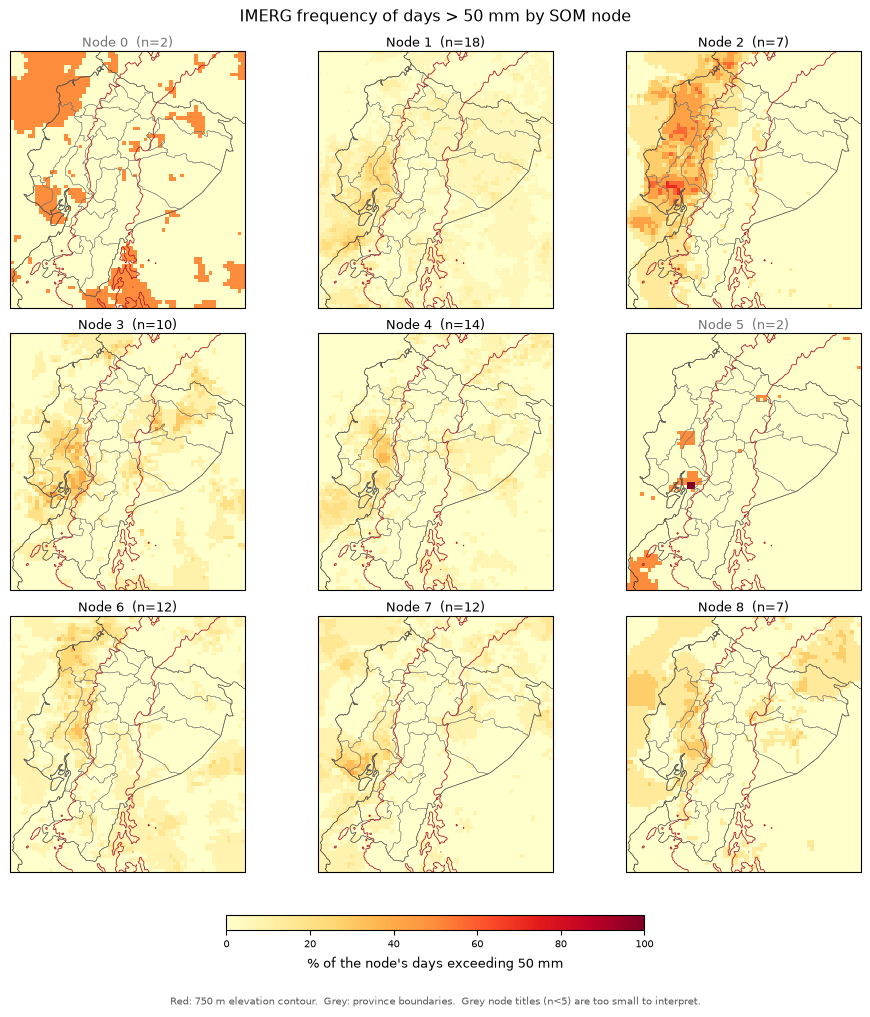

In [10]:
fig_i_50 = node_map_grid(
    imerg, "freq_gt50", plt.get_cmap("YlOrRd"), vmax=100,
    cbar_label="% of the node's days exceeding 50 mm",
    title="IMERG frequency of days > 50 mm by SOM node",
    fname="06_imerg_node_freq50.png", extend="neither")

## 6. The two products, node by node

Notebook 01 found the CHIRPS/IMERG ratio is not a constant: IMERG exceeds CHIRPS on near-dry
days and falls to roughly a third of it above 60 mm/day. These are the heaviest days in the
record, so this is where that disagreement should be largest — and where it most affects any
conclusion drawn from one product alone.

In [11]:
rows = []
for k in range(N_NODES):
    nc, ni = int(chirps.n_days.values[k]), int(imerg.n_days.values[k])
    if nc == 0 or ni == 0:
        continue
    cm = float(np.nanmean(chirps.mean_precip.isel(node=k).values))
    im = float(np.nanmean(imerg.mean_precip.isel(node=k).values))
    rows.append({
        "node": k, "n_chirps": nc, "n_imerg": ni,
        "CHIRPS mean": round(cm, 2), "IMERG mean": round(im, 2),
        "ratio": round(im / cm, 3),
        "CHIRPS %>25": round(float(np.nanmean(chirps.freq_gt25.isel(node=k).values)), 1),
        "IMERG %>25": round(float(np.nanmean(imerg.freq_gt25.isel(node=k).values)), 1),
    })
cmp_tab = pd.DataFrame(rows)
print(cmp_tab.to_string(index=False))

well_sampled = cmp_tab[(cmp_tab.n_imerg >= 7)]
print(f"\nratio across nodes: min {cmp_tab.ratio.min():.3f}  max {cmp_tab.ratio.max():.3f}")
print(f"ratio, nodes with n_imerg >= 7 (n={len(well_sampled)}): "
      f"mean {well_sampled.ratio.mean():.3f}  spread "
      f"{well_sampled.ratio.min():.3f}-{well_sampled.ratio.max():.3f}")
cmp_tab.to_csv(DATA_DIR / "som_node_precip_chirps_vs_imerg.csv", index=False)

 node  n_chirps  n_imerg  CHIRPS mean  IMERG mean  ratio  CHIRPS %>25  IMERG %>25
    0         4        2        28.34       22.24  0.785         37.1        32.1
    1        26       18        17.91       11.53  0.644         21.1        14.7
    2         9        7        19.95       14.20  0.712         21.3        16.3
    3        13       10        18.15       14.02  0.772         23.0        19.6
    4        18       14        16.69       11.84  0.709         19.0        14.5
    5         8        2        14.09        6.73  0.478         16.5         6.2
    6        20       12        18.63       12.84  0.689         24.6        16.7
    7        27       12        15.23       12.51  0.821         18.8        15.1
    8        12        7        16.56       12.67  0.765         22.9        14.3

ratio across nodes: min 0.478  max 0.821
ratio, nodes with n_imerg >= 7 (n=7): mean 0.730  spread 0.644-0.821


## 7. What to take from this

**The nodes differ in rainfall geography, not just rainfall amount.** This is the payoff of
compositing the gridded field rather than a province mean: nodes with comparable area-average
totals put the rain in visibly different places, and the exceedance maps separate them further
than the means do. A classification built purely on 850 hPa wind, with no rainfall information
given to it, nonetheless sorts days into distinguishable precipitation patterns — which is the
main evidence that the SOM is capturing something physical rather than partitioning noise.

**The mean and the exceedance maps are not interchangeable.** The Andean slope carries a
persistent mean-rainfall maximum in nearly every node — orography does its work whatever the
synoptic pattern — while the >50 mm maps are patchier and more node-specific. If the question is
where flooding risk changes with circulation type, the exceedance maps answer it and the mean
maps mislead.

**The product disagreement is large and structured, exactly as notebook 01 predicted.** The
node-mean ratio runs 0.48–0.82 and varies between nodes; it is not a constant offset that could
be divided out. Any statement of the form "node *k* averages *X* mm/day" is a statement about a
product, not about the atmosphere, and should be written that way.

Do not try to reconcile these ratios with the 0.47 quoted in notebook 01 for heavy days — they
are different quantities. Notebook 01 averaged over Guayas province only; these average over the
whole Ecuador window, which includes drier terrain where IMERG sits closer to (or above) CHIRPS.
Both are correct for what they measure, which is itself the point: a product ratio is a property
of the domain and intensity range it was computed over, not a transferable constant.

**Small nodes stay uninterpretable, and doubly so for IMERG.** Nodes below ~5 days are annotated
in grey throughout. For IMERG the effective sample is smaller again because the record starts in
2000. An isolated 100% cell in a two-day composite means "it happened both days" — which is a
statement about two days, not a climatology.

### If you take this further

- **Composite the anomaly, not the total.** Every node shows the Andean maximum because the
  climatology does. Dividing by (or subtracting) a day-of-year climatology would isolate what is
  specific to each circulation type — the more informative question, and a direct extension of
  the fields already computed here.
- **Test the separation.** The claim that nodes produce distinguishable rainfall patterns is
  made by eye above. A spatial correlation matrix between node composites, or a permutation test
  against randomly shuffled node labels, would make it quantitative.
- **Widen the day list.** The sample-size ceiling on every node traces back to the top-250
  selection in notebook 02. A percentile-based threshold would grow every node at once.